<a href="https://colab.research.google.com/github/kanishkaapatra/Machine-Learning_projects/blob/main/copp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()  # select just the quicklook.png and the .kml file


Saving quick-look.png to quick-look.png
Saving map-overlay.kml to map-overlay.kml


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'quick-look.png', '.ipynb_checkpoints', 'map-overlay.kml', 'oil-spill-detection(mod).ipynb', 'unet_oilspill_model.h5', 'sample_data']


In [ ]:
quicklook_path = None
kml_path = None

for f in os.listdir('/content'):
    if f.lower().endswith('.png') or f.lower().endswith('.jpg'):
        quicklook_path = os.path.join('/content', f)
    if f.lower().endswith('.kml'):
        kml_path = os.path.join('/content', f)

print("Quicklook image:", quicklook_path)
print("KML file:", kml_path)

Quicklook image: /content/quick-look.png
KML file: /content/map-overlay.kml


In [ ]:
import re

with open(kml_path, 'r') as f:
    kml_content = f.read()

# Find the coordinates block inside the KML
match = re.search(r'<coordinates>(.*?)</coordinates>', kml_content, re.DOTALL)
coord_text = match.group(1).strip()

# Parse into a list of (lon, lat) pairs
coord_pairs = coord_text.split()
corners = []
for pair in coord_pairs:
    lon, lat, *_ = pair.split(',')
    corners.append((float(lon), float(lat)))

print("Image corners (lon, lat):", corners)

Image corners (lon, lat): [(2.838639, 54.587452), (6.844923, 55.002739), (7.236072, 53.50872), (3.369789, 53.096958)]


In [ ]:
import kagglehub
nabilsherif_oil_spill_path = kagglehub.dataset_download('nabilsherif/oil-spill')


Using Colab cache for faster access to the 'oil-spill' dataset.


In [ ]:
print(nabilsherif_oil_spill_path)

/kaggle/input/oil-spill


In [ ]:
import os
for root, dirs, files_ in os.walk(nabilsherif_oil_spill_path):
    level = root.replace(nabilsherif_oil_spill_path, '').count(os.sep)
    if level <= 3:
        print('  ' * level + os.path.basename(root) + '/')

oil-spill/
  oil-spill/
    test/
      labels/
      images/
    train/
      labels/
      images/


In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CLASSES = 5
IMG_CHANNELS = 3

IMG_PATH = nabilsherif_oil_spill_path + '/oil-spill/train/images'
LABELS_PATH = nabilsherif_oil_spill_path + '/oil-spill/train/labels'
IMG_PATH_TEST = nabilsherif_oil_spill_path + '/oil-spill/test/images'
LABELS_PATH_TEST = nabilsherif_oil_spill_path + '/oil-spill/test/labels'

IMG_IDS = sorted(os.listdir(IMG_PATH))
LABELS_IDS = sorted(os.listdir(LABELS_PATH))
IMG_IDS_TEST = sorted(os.listdir(IMG_PATH_TEST))
LABELS_IDS_TEST = sorted(os.listdir(LABELS_PATH_TEST))

print(len(IMG_IDS), len(LABELS_IDS), len(IMG_IDS_TEST), len(LABELS_IDS_TEST))

1002 1002 110 110


In [ ]:
import numpy as np
import cv2
from tqdm import tqdm
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
COLOR_MAP = [[0,0,0],[0,255,255],[255,0,0],[153,76,0],[0,153,0]]

def process_mask(rgb_mask, colormap):
    output_mask = []
    for color in colormap:
        output_mask.append(np.all(np.equal(rgb_mask, color), axis=-1))
    return np.stack(output_mask, axis=-1)

In [ ]:
train_images, train_masks = [], []

for image_filename, mask_filename in tqdm(zip(IMG_IDS, LABELS_IDS), total=len(IMG_IDS)):
    image = cv2.imread(os.path.join(IMG_PATH, image_filename), cv2.IMREAD_COLOR)
    image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH)) / 255.0

    mask = cv2.imread(os.path.join(LABELS_PATH, mask_filename), cv2.IMREAD_COLOR)
    mask = cv2.resize(mask, (IMG_HEIGHT, IMG_WIDTH))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    processed = process_mask(mask, COLOR_MAP)
    grayscale_mask = np.expand_dims(np.argmax(processed, axis=-1), axis=-1)

    train_images.append(image)
    train_masks.append(grayscale_mask)

train_images = np.array(train_images)
train_masks = np.array(train_masks)
train_masks_cat = to_categorical(train_masks, num_classes=5)
print(train_images.shape, train_masks_cat.shape)

100%|██████████| 1002/1002 [00:39<00:00, 25.39it/s]


(1002, 256, 256, 3) (1002, 256, 256, 5)


In [ ]:
def UNet(input_shape, IMG_CLASSES):
    inputs = Input(input_shape)
    c1 = Conv2D(16,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(inputs)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(32,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(64,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(c3)
    p3 = MaxPooling2D((2,2))(c3)

    c4 = Conv2D(128,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(c4)
    p4 = MaxPooling2D((2,2))(c4)

    c5 = Conv2D(256,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(c5)

    u6 = Conv2DTranspose(128,(2,2),strides=(2,2),padding="same")(c5)
    u6 = concatenate([u6,c4])
    c6 = Conv2D(128,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(c6)

    u7 = Conv2DTranspose(64,(2,2),strides=(2,2),padding="same")(c6)
    u7 = concatenate([u7,c3])
    c7 = Conv2D(64,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(c7)

    u8 = Conv2DTranspose(32,(2,2),strides=(2,2),padding="same")(c7)
    u8 = concatenate([u8,c2])
    c8 = Conv2D(32,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(c8)

    u9 = Conv2DTranspose(16,(2,2),strides=(2,2),padding="same")(c8)
    u9 = concatenate([u9,c1],axis=3)
    c9 = Conv2D(16,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16,(3,3),activation="relu",kernel_initializer="he_normal",padding="same")(c9)

    outputs = Conv2D(IMG_CLASSES,(1,1),activation="softmax")(c9)
    return Model(inputs, outputs)

model = UNet((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), IMG_CLASSES)

In [ ]:
tf.keras.backend.clear_session()
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_images, train_masks_cat, epochs=25, batch_size=16, validation_split=0.1, verbose=1)

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 68s 614ms/step - accuracy: 0.8369 - loss: 0.6786 - val_accuracy: 0.8967 - val_loss: 0.4862
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.8825 - loss: 0.4927 - val_accuracy: 0.9034 - val_loss: 0.4232
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.8872 - loss: 0.4160 - val_accuracy: 0.9160 - val_loss: 0.3482
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.8892 - loss: 0.3753 - val_accuracy: 0.9166 - val_loss: 0.2742
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.8882 - loss: 0.3520 - val_accuracy: 0.9156 - val_loss: 0.2769
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.8933 - loss: 0.3168 - val_accuracy: 0.9270 - val_loss: 0.2196
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.9059 - loss: 0.2832 - val_accuracy: 0.9317 - val_loss: 0.2226
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.9035 - loss: 0.2852 - val_accuracy: 0

In [ ]:
model.save('/content/unet_oilspill_model.h5')
print("Model saved")

Model saved


In [ ]:
def pixel_to_latlon(px, py, img_width, img_height, corners):
    top_left, top_right, bottom_right, bottom_left = corners[0], corners[1], corners[2], corners[3]
    fx, fy = px / img_width, py / img_height
    top_lon = top_left[0] + fx * (top_right[0] - top_left[0])
    top_lat = top_left[1] + fx * (top_right[1] - top_left[1])
    bottom_lon = bottom_left[0] + fx * (bottom_right[0] - bottom_left[0])
    bottom_lat = bottom_left[1] + fx * (bottom_right[1] - bottom_left[1])
    lon = top_lon + fy * (bottom_lon - top_lon)
    lat = top_lat + fy * (bottom_lat - top_lat)
    return lat, lon

from shapely.geometry import Polygon

def detect_spill_with_coordinates(image_path, model, corners, oil_class_id=1):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image_resized = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
    pred = model.predict(np.expand_dims(image_resized, axis=0))[0]
    pred_mask = np.argmax(pred, axis=-1)
    oil_mask = (pred_mask == oil_class_id).astype(np.uint8)
    confidence = float(pred[:,:,oil_class_id][pred_mask==oil_class_id].mean()) if oil_mask.sum()>0 else 0.0

    contours, _ = cv2.findContours(oil_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    regions = []
    for c in contours:
        if cv2.contourArea(c) > 5 and len(c) >= 3:
            centroid_px = c.mean(axis=0).squeeze()
            lat, lon = pixel_to_latlon(centroid_px[0], centroid_px[1], IMG_WIDTH, IMG_HEIGHT, corners)
            regions.append({"area_pixels": float(cv2.contourArea(c)), "centroid": {"lat": lat, "lon": lon}})

    return {"confidence": confidence, "oil_area_pixels": int(oil_mask.sum()), "num_regions": len(regions), "regions": regions}

result = detect_spill_with_coordinates('/content/quick-look.png', model, corners)
print(f"Confidence: {result['confidence']:.2%}")
print(f"Regions detected: {result['num_regions']}")
for i, r in enumerate(result['regions']):
    print(f"Region {i+1}: {r['area_pixels']:.1f} px, location: {r['centroid']['lat']:.5f}, {r['centroid']['lon']:.5f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Confidence: 61.17%
Regions detected: 2
Region 1: 7.0 px, location: 54.23245, 7.01238
Region 2: 1573.5 px, location: 53.92042, 3.11330


In [ ]:
test_images, test_masks = [], []

for image_filename, mask_filename in tqdm(zip(IMG_IDS_TEST, LABELS_IDS_TEST), total=len(IMG_IDS_TEST)):
    image = cv2.imread(os.path.join(IMG_PATH_TEST, image_filename), cv2.IMREAD_COLOR)
    image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH)) / 255.0
    mask = cv2.imread(os.path.join(LABELS_PATH_TEST, mask_filename), cv2.IMREAD_COLOR)
    mask = cv2.resize(mask, (IMG_HEIGHT, IMG_WIDTH))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    processed = process_mask(mask, COLOR_MAP)
    test_images.append(image)
    test_masks.append(np.expand_dims(np.argmax(processed, axis=-1), axis=-1))

test_images = np.array(test_images)
test_masks = np.array(test_masks)

from sklearn.metrics import precision_score, recall_score, f1_score
prediction = model.predict(test_images)
true_labels = test_masks.flatten()
pred_labels = np.argmax(prediction, axis=-1).flatten()

print("Precision:", precision_score(true_labels, pred_labels, average='weighted'))
print("Recall:", recall_score(true_labels, pred_labels, average='weighted'))
print("F1:", f1_score(true_labels, pred_labels, average='weighted'))

100%|██████████| 110/110 [00:07<00:00, 14.81it/s]


4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.93504166056755
Recall: 0.9450076016512784
F1: 0.9323147494060756


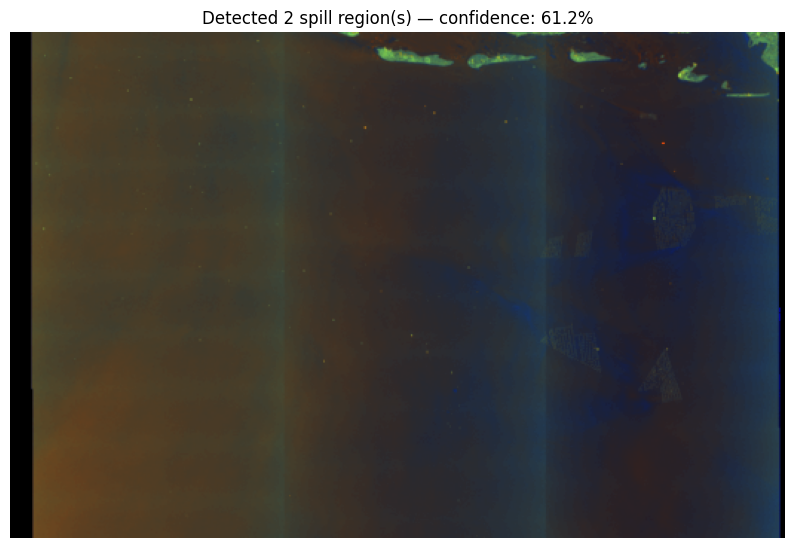

In [ ]:
image = cv2.cvtColor(cv2.imread('quick-look.png'), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.title(f"Detected {result['num_regions']} spill region(s) — confidence: {result['confidence']:.1%}")
plt.axis('off')
plt.show()